# 04 — Modèle Deep Learning (MLP PyTorch)

**Architecture** : Multi-Layer Perceptron (MLP) avec :  
- Couches Dense → BatchNorm → ReLU → Dropout  
- Optimiseur Adam + ReduceLROnPlateau  
- Perte BCELoss (classification binaire)  

**Données** : mêmes features preprocessées que les modèles ML (26 features)

### 1 - Chargement des données 

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

PROC_PATH = Path('../data/processed')
DL_PATH   = Path('../models/dl')
FIGS_PATH = Path('../reports/figures')
DL_PATH.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

# Chargement
X_train = np.load(PROC_PATH / 'X_train.npy').astype(np.float32)
X_test  = np.load(PROC_PATH / 'X_test.npy').astype(np.float32)
y_train = np.load(PROC_PATH / 'y_train.npy').astype(np.float32)
y_test  = np.load(PROC_PATH / 'y_test.npy').astype(np.float32)
feat_names = np.load(PROC_PATH / 'feature_names.npy', allow_pickle=True)

print(f'X_train : {X_train.shape}  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   y_test  : {y_test.shape}')
print(f'Input dim : {X_train.shape[1]}')

Device : cpu
X_train : (814, 26)  y_train : (814,)
X_test  : (184, 26)   y_test  : (184,)
Input dim : 26


### 2 - DataLoaders PyTorch

In [15]:
BATCH_SIZE = 32

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches train : {len(train_dl)}  |  Batches test : {len(test_dl)}')

Batches train : 26  |  Batches test : 6


### 3 - Architecture du réseau

In [16]:
class HeartMLP(nn.Module):
    """
    MLP pour classification binaire.
    Architecture : Input → [Linear → BatchNorm → ReLU → Dropout] × N → Linear → Sigmoid
    """
    def __init__(self, input_dim: int, hidden_dims: list, dropout: float = 0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev_dim = h
        layers += [nn.Linear(prev_dim, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


# Instanciation
INPUT_DIM   = X_train.shape[1]
HIDDEN_DIMS = [128, 64, 32]
DROPOUT     = 0.3

model = HeartMLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal paramètres    : {total_params:,}')
print(f'Paramètres entraînables : {train_params:,}')

HeartMLP(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total paramètres    : 14,273
Paramètres entraînables : 14,273


### 4 - Fonctions d'entraînement & d'évaluation

In [17]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
        correct    += ((preds >= 0.5).float() == yb).sum().item()
        total      += len(xb)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_proba, all_labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        proba = model(xb)
        loss  = criterion(proba, yb)
        total_loss += loss.item() * len(xb)
        correct    += ((proba >= 0.5).float() == yb).sum().item()
        total      += len(xb)
        all_proba.extend(proba.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_labels), np.array(all_proba))

### 4 - Entraînement

In [18]:
EPOCHS = 120
LR     = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5
)
criterion = nn.BCELoss()

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_auc':[]}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc             = train_epoch(model, train_dl, optimizer, criterion)
    val_loss, val_acc, lbl, prb = eval_epoch(model, test_dl, criterion)
    val_auc                     = roc_auc_score(lbl, prb)
    scheduler.step(val_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), DL_PATH / 'best_mlp.pt')

    if epoch % 20 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  '
              f'val_acc={val_acc:.4f}  val_auc={val_auc:.4f}  '
              f'lr={lr_now:.6f}')

print(f'\nMeilleure val_acc : {best_acc:.4f}  →  modèle sauvegardé')

Epoch   1/120  train_loss=0.6212  val_loss=0.5424  val_acc=0.7935  val_auc=0.8920  lr=0.001000
Epoch  20/120  train_loss=0.3392  val_loss=0.3634  val_acc=0.8478  val_auc=0.9149  lr=0.001000
Epoch  40/120  train_loss=0.2765  val_loss=0.3670  val_acc=0.8424  val_auc=0.9191  lr=0.000250
Epoch  60/120  train_loss=0.2722  val_loss=0.3749  val_acc=0.8370  val_auc=0.9158  lr=0.000063
Epoch  80/120  train_loss=0.2616  val_loss=0.3720  val_acc=0.8370  val_auc=0.9156  lr=0.000031
Epoch 100/120  train_loss=0.2616  val_loss=0.3722  val_acc=0.8315  val_auc=0.9163  lr=0.000008
Epoch 120/120  train_loss=0.2743  val_loss=0.3770  val_acc=0.8424  val_auc=0.9155  lr=0.000002

Meilleure val_acc : 0.8641  →  modèle sauvegardé


### 5 - Courbes d'apprentissage

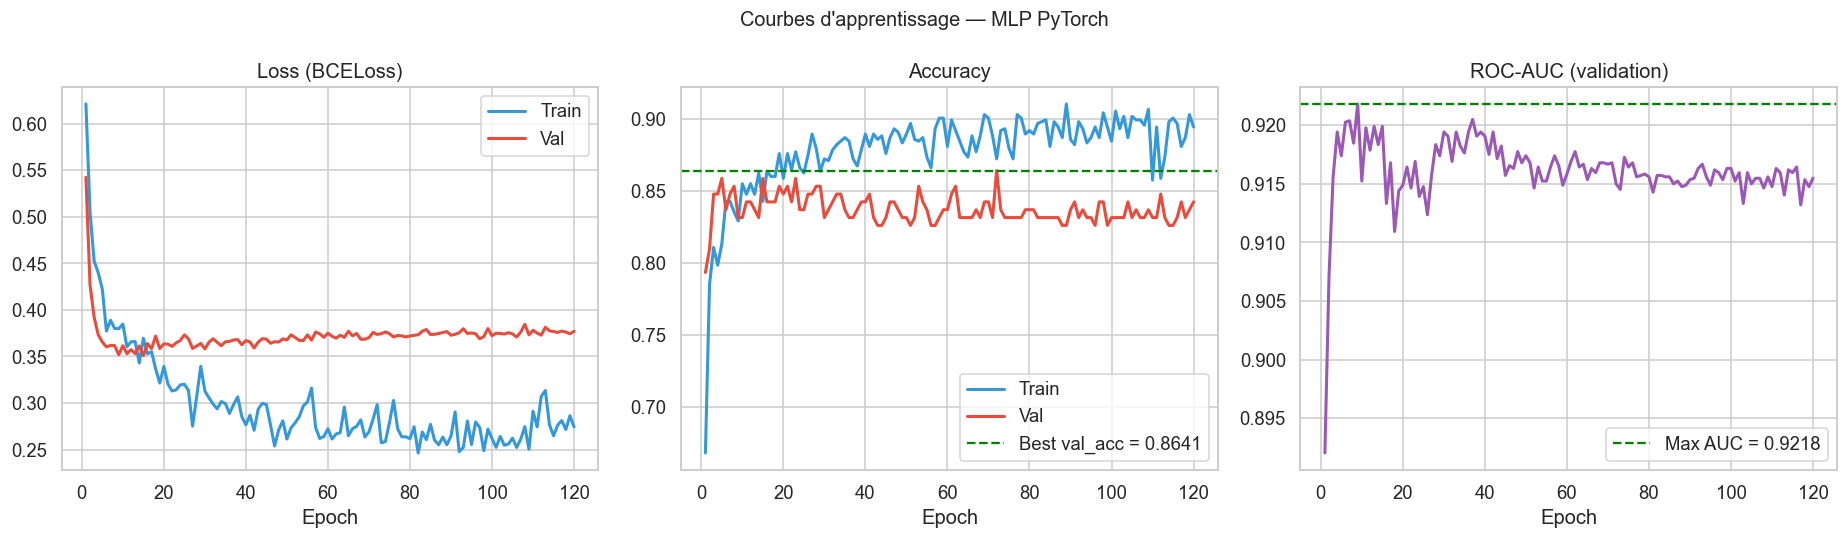

In [19]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='#3498db', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='#e74c3c', linewidth=2)
axes[0].set_title('Loss (BCELoss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train', color='#3498db', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   label='Val',   color='#e74c3c', linewidth=2)
axes[1].axhline(best_acc, color='green', linestyle='--', linewidth=1.5,
                label=f'Best val_acc = {best_acc:.4f}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# ROC-AUC
axes[2].plot(epochs_range, history['val_auc'], color='#9b59b6', linewidth=2)
axes[2].axhline(max(history['val_auc']), color='green', linestyle='--', linewidth=1.5,
                label=f'Max AUC = {max(history["val_auc"]):.4f}')
axes[2].set_title('ROC-AUC (validation)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Courbes d\'apprentissage — MLP PyTorch', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_PATH / '16_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 6 - Évaluation finale (meilleur modèle)

=== ÉVALUATION FINALE — Meilleur MLP ===
Accuracy  : 0.8641
ROC-AUC   : 0.9150

              precision    recall  f1-score   support

        Sain       0.86      0.83      0.84        82
      Malade       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



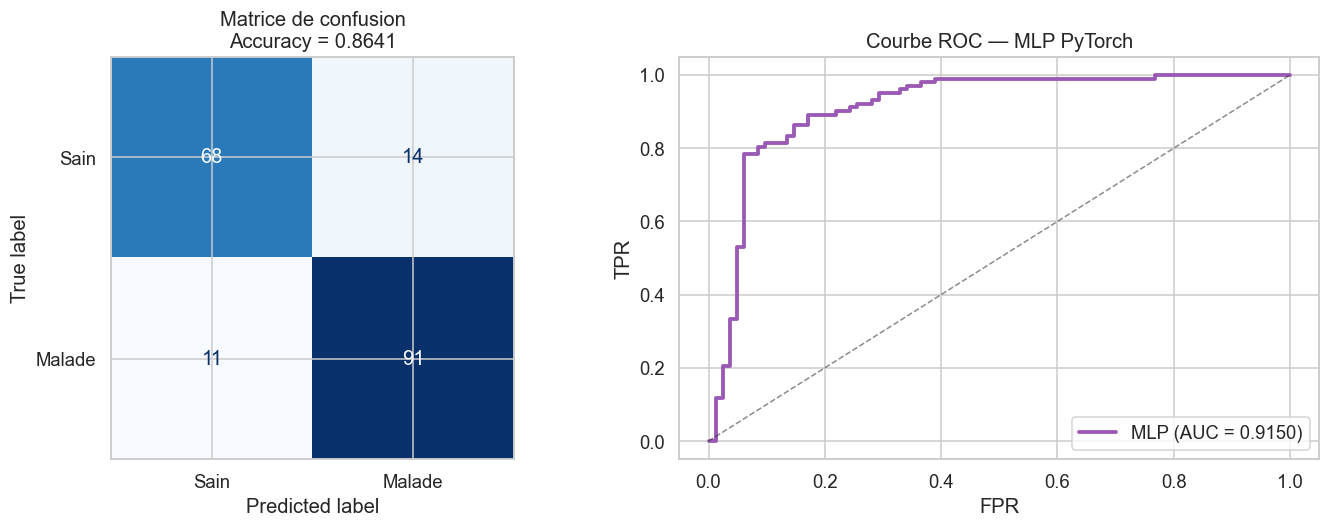

In [20]:
# Charger le meilleur modèle
best_model = HeartMLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE)
best_model.load_state_dict(torch.load(DL_PATH / 'best_mlp.pt', map_location=DEVICE))
best_model.eval()

_, _, y_true, y_proba = eval_epoch(best_model, test_dl, criterion)
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_proba)

print('=== ÉVALUATION FINALE — Meilleur MLP ===')
print(f'Accuracy  : {acc:.4f}')
print(f'ROC-AUC   : {auc:.4f}')
print(f'\n{classification_report(y_true, y_pred, target_names=["Sain", "Malade"])}')

# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                       display_labels=['Sain', 'Malade']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matrice de confusion\nAccuracy = {acc:.4f}')

fpr, tpr, _ = roc_curve(y_true, y_proba)
axes[1].plot(fpr, tpr, color='#9b59b6', linewidth=2.5, label=f'MLP (AUC = {auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('Courbe ROC — MLP PyTorch')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGS_PATH / '17_dl_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### 7 - Comparaison ML vs DL

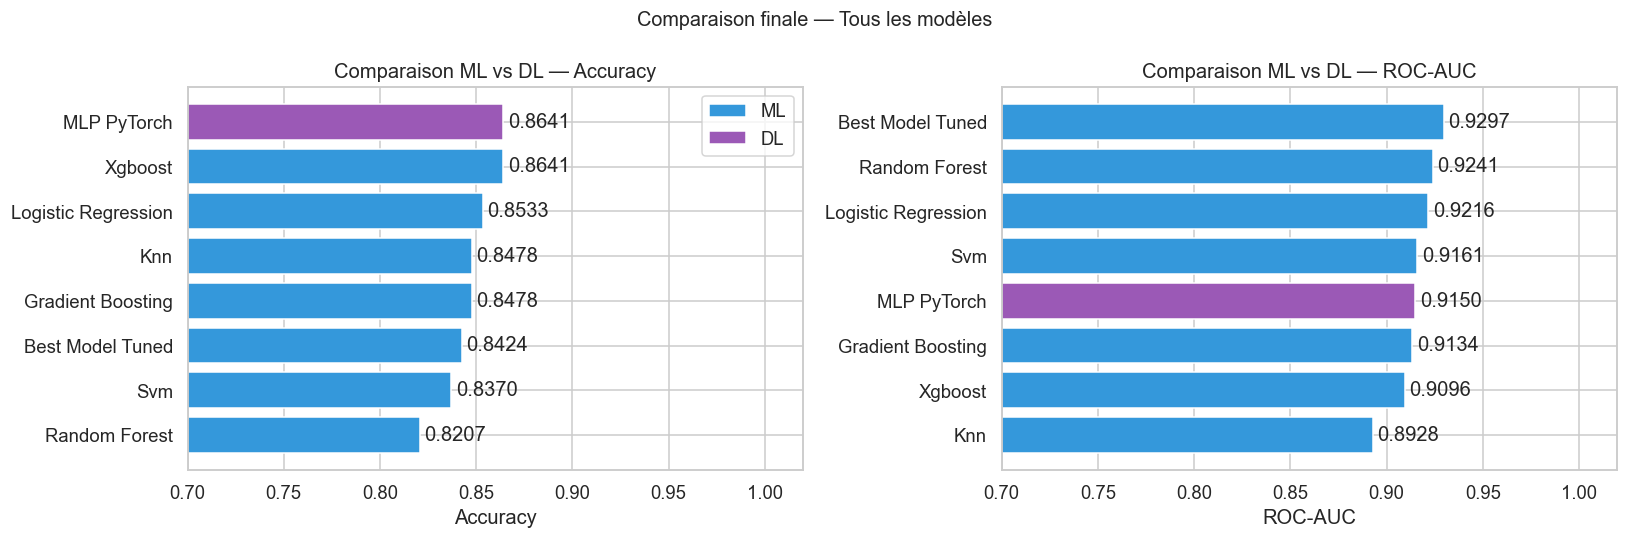


=== TABLEAU FINAL ===


,Modèle,Type,Accuracy,ROC-AUC
0,Xgboost,ML,0.864100,0.909600
1,MLP PyTorch,DL,0.864100,0.915000
2,Logistic Regression,ML,0.853300,0.921600
3,Gradient Boosting,ML,0.847800,0.913400
4,Knn,ML,0.847800,0.892800
5,Best Model Tuned,ML,0.842400,0.929700
6,Svm,ML,0.837000,0.916100
7,Random Forest,ML,0.820700,0.924100


In [21]:
import joblib
ML_PATH = Path('../models/ml')

comparison = []
for f in sorted(ML_PATH.glob('*.joblib')):
    if any(skip in f.stem for skip in ['imputer','scaler','encoder','preprocessor']):
        continue
    m = joblib.load(f)
    yp = m.predict(X_test)
    ypr = m.predict_proba(X_test)[:,1] if hasattr(m,'predict_proba') else None
    comparison.append({
        'Modèle':    f.stem.replace('_', ' ').title(),
        'Type':      'ML',
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, ypr), 4) if ypr is not None else None
    })

# Ajouter DL
comparison.append({
    'Modèle':  'MLP PyTorch',
    'Type':    'DL',
    'Accuracy': round(acc, 4),
    'ROC-AUC':  round(auc, 4)
})

df_cmp = pd.DataFrame(comparison).sort_values('Accuracy', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#9b59b6' if t == 'DL' else '#3498db' for t in df_cmp.sort_values('Accuracy')['Type']]

for ax, metric in zip(axes, ['Accuracy', 'ROC-AUC']):
    df_s = df_cmp.sort_values(metric)
    bars = ax.barh(df_s['Modèle'], df_s[metric],
                   color=['#9b59b6' if t=='DL' else '#3498db' for t in df_s['Type']],
                   edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.set_xlabel(metric)
    ax.set_title(f'Comparaison ML vs DL — {metric}')
    ax.set_xlim(0.7, 1.02)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='ML'), Patch(facecolor='#9b59b6', label='DL')]
axes[0].legend(handles=legend_elements)

plt.suptitle('Comparaison finale — Tous les modèles', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_PATH / '18_ml_vs_dl.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== TABLEAU FINAL ===')
df_cmp.style.background_gradient(subset=['Accuracy','ROC-AUC'], cmap='YlGn')